<div class="nt-cover">
  <div class="nt-head">
    <span class="nt-label">NOTE TECHNIQUE</span>
    <span class="nt-num">01</span>
  </div>
  <div class="nt-title">Classer les variables tarifaires</div>
  <p class="nt-lede">Avant de construire un modèle de fréquence ou de coût moyen, il faut
  savoir quelles variables regarder. Sur un portefeuille automobile dont les variables sont
  de types melangés, l'usage impose une méthode de corrélation par croisement de types.
  Ce carnet compare cet usage à un indicateur unique, phi-K.</p>
  <div class="nt-meta">
    <div>
      <span class="nt-label nt-label-ink">DONNÉES</span>
      <p>freMPL3, assureur automobile français</p>
    </div>
    <div>
      <span class="nt-label nt-label-ink">PÉRIMÈTRE</span>
      <p>20 600 polices, exercice 2004</p>
    </div>
    <div>
      <span class="nt-label nt-label-ink">CIBLES</span>
      <p>Fréquence et coût moyen</p>
    </div>
  </div>
  <div class="nt-foot">
    <span>ARNAUD MBARGA</span>
    <span class="nt-src">Baak et al., 2019</span>
  </div>
</div>

In [2]:
import logging
from pathlib import Path
import matplotlib as mpl
from matplotlib import font_manager
from IPython.display import HTML, display

############################ Chargement de la charte
CSS = Path("charte_notebook.css").read_text(encoding = "utf-8")
display(HTML(f"<style>{CSS}</style>"))

############################ Configuration de la police
POLICE = "IBM Plex Sans"
polices_disponibles = {font.name for font in font_manager.fontManager.ttflist}
mpl.rcParams["font.family"] = POLICE if POLICE in polices_disponibles else "DejaVu Sans"
mpl.rcParams["font.sans-serif"] = [POLICE, "DejaVu Sans", "Arial", "sans-serif"]
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

<h4>Sommaire</h4>

<div class="nt-toc">
  <a class="nt-toc-item" href="#part_1" style="text-decoration: none; color: inherit;"><span class="nt-n">01</span><span class="nt-t">Un cas où les trois indicateurs divergent</span><span class="nt-x">1 figure</span></a>
  <a class="nt-toc-item" href="#part_2" style="text-decoration: none; color: inherit;"><span class="nt-n">02</span><span class="nt-t">Les indicateurs et leurs conditions d'emploi</span><span class="nt-x">1 tableau</span></a>
  <a class="nt-toc-item" href="#part_3" style="text-decoration: none; color: inherit;"><span class="nt-n">03</span><span class="nt-t">La base tarifaire</span><span class="nt-x">2 cibles</span></a>
  <a class="nt-toc-item" href="#part_4" style="text-decoration: none; color: inherit;"><span class="nt-n">04</span><span class="nt-t">Classement des variables par phi-K</span><span class="nt-x">2 figures</span></a>
  <a class="nt-toc-item" href="#part_5" style="text-decoration: none; color: inherit;"><span class="nt-n">05</span><span class="nt-t">Le même classement par les méthodes classiques</span><span class="nt-x">3 méthodes</span></a>
  <a class="nt-toc-item" href="#part_6" style="text-decoration: none; color: inherit;"><span class="nt-n">06</span><span class="nt-t">Dépendances entre covariables</span><span class="nt-x">2 matrices</span></a>
  <a class="nt-toc-item" href="#part_7" style="text-decoration: none; color: inherit;"><span class="nt-n">07</span><span class="nt-t">Limites</span><span class="nt-x">1 page</span></a>
</div>


In [3]:
%matplotlib inline

############################ Dépendances
# pip install pyreadr phik pandas scipy matplotlib
import os
import time
import urllib.request
import warnings
from itertools import combinations

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyreadr
from phik import phik_from_array, phik_matrix, significance_matrix
from scipy.stats import chi2_contingency, norm, pearsonr, spearmanr
warnings.filterwarnings("ignore")

############################ Charte graphique
IVORY, INK, VIOLET = "#F7F5F1", "#0B0D12", "#3B2A55"
GREY, GREY2, RULE = "#3E3B36", "#5C584F", "#D6D1C7"
mpl.rcParams.update({
    "figure.facecolor": IVORY, "axes.facecolor": IVORY, "savefig.facecolor": IVORY,
    "font.family": "IBM Plex Sans", "font.size": 10,
    "text.color": GREY, "axes.labelcolor": GREY2, "axes.edgecolor": RULE,
    "xtick.color": GREY2, "ytick.color": GREY2,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titlelocation": "left", "axes.titlepad": 14,
    "axes.prop_cycle": mpl.cycler(color = [INK, VIOLET, GREY2])
})
CMAP = mpl.colors.LinearSegmentedColormap.from_list("nt", [IVORY, VIOLET])

<div class="nt-section" id="part_1">
  <span class="nt-n">01</span>
  <span class="nt-t">Un cas où les trois indicateurs divergent</span>
</div>

<p class="nt-lede">Une fréquence simulée qui dépend de l'âge du conducteur selon une
parabole centrée sur 50 ans. La dépendance est déterministe, au bruit près. Trois
indicateurs sont calculés sur ces mêmes données.</p>

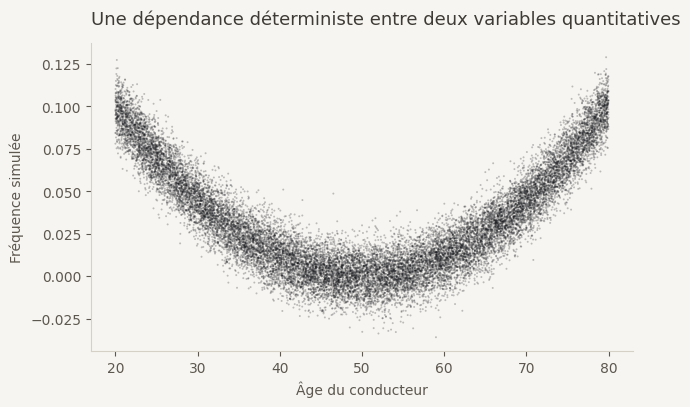

,Valeur
Pearson,-0.003
Spearman,0.006
phi-K,0.852


In [4]:
############################ Simulation d'une dépendance en U
rng = np.random.default_rng(0)
age = rng.uniform(20, 80, 20_000)
freq_simulee = 0.10 * ((age - 50) / 30) ** 2 + rng.normal(0, 0.01, 20_000)

############################ Représentation
fig, ax = plt.subplots(figsize = (7, 4))
ax.scatter(age, freq_simulee, s = 2, alpha = 0.25, color = INK, edgecolors = "none")
ax.set_xlabel("Âge du conducteur")
ax.set_ylabel("Fréquence simulée")
ax.set_title("Une dépendance déterministe entre deux variables quantitatives")
plt.show()

############################ Comparaison des trois indicateurs
pd.DataFrame({
    "Valeur": [
        pearsonr(age, freq_simulee)[0],
        spearmanr(age, freq_simulee)[0],
        phik_from_array(age, freq_simulee, num_vars = ["x", "y"])
    ]
}, index = ["Pearson", "Spearman", "phi-K"]).round(3)

<p class="nt-caption">Deux variables quantitatives, aucune donnée manquante, aucune valeur
extrême.</p>

<p>Pearson et Spearman renvoient des valeurs proches de zéro. Ce n'est pas une erreur de
mesure : Pearson quantifie la composante linéaire, Spearman la composante monotone, et la
parabole n'a ni l'une ni l'autre. Les deux répondent correctement à la question qu'ils
posent, qui n'est pas celle qu'on leur pose ici.</p>

<p>La courbe en U entre âge et sinistralité est un cas courant en tarification. Sur une
matrice de corrélation portant sur plusieurs dizaines de variables, une dépendance de
cette forme passe inaperçue.</p>

<div class="nt-section" id="part_2">
  <span class="nt-n">02</span>
  <span class="nt-t">Les indicateurs et leurs conditions d'emploi</span>
</div>

<p class="nt-lede">Chaque coefficient répond à une question précise, sur des types de
variables précis. Le tableau rassemble ce qui détermine le choix en pratique.</p>

| Indicateur | Ce qu'il mesure | Types admis | Conditions et limites | Borne |
| ---------- | --------------- | ----------- | --------------------- | ----- |
| **Pearson** | Intensité et sens d'une relation linéaire | Deux quantitatives | Relation linéaire, sensibilité aux valeurs extrêmes | de -1 à 1 |
| **Spearman** | Intensité et sens d'une relation monotone | Quantitatives, ordinales | Monotonie, équidistance implicite des rangs | de -1 à 1 |
| **Kendall** | Concordance des paires | Quantitatives, ordinales | Monotonie, coût de calcul plus élevé que Spearman | de -1 à 1 |
| **Rapport eta** | Part de variance expliquée par les modalités | Quantitative croisée nominale | Croît avec le nombre de modalités | de 0 à 1 |
| **V de Cramér** | Intensité d'une association | Deux nominales | Dépend du nombre de modalités, instable à faible effectif | de 0 à 1 |
| **phi-K** | Intensité d'une dépendance, linéaire ou non | Tous types | Discrétisation des continues, coût de calcul supérieur | de 0 à 1 |

<p>Les quatre premiers imposent une segmentation préalable du jeu de variables par type.
Le cinquième est défini pour les seules nominales. phi-K applique la même formule aux six
croisements possibles et se cale sur Pearson dans le cas gaussien bivarié, ce qui permet
de conserver ses repères de lecture.</p>

<div class="nt-note">
Définition et propriétés de phi-K : M. Baak, R. Koopman, H. Snoek, S. Klous,
<em>A new corrélation coefficient between categorical, ordinal and interval variables with
Pearson characteristics</em>, arXiv:1811.11440, 2019.
<à href="https://arxiv.org/abs/1811.11440">arxiv.org/abs/1811.11440</à>.
Implementation : <code>pip install phik</code>, documentation sur
<à href="https://phik.readthedocs.io">phik.readthedocs.io</à>.
</div>

<div class="nt-section" id="part_3">
  <span class="nt-n">03</span>
  <span class="nt-t">La base tarifaire</span>
</div>

<p class="nt-lede">freMPL3 provient d'un assureur automobile français privé, exercice 2004.
Chaque ligne est une police observée sur une période de l'exercice, avec son exposition,
un indicateur de sinistre et le montant associé. La documentation précise que l'indicateur
et le montant portent sur la garantie, et non sur le nombre de sinistres.</p>

In [5]:
############################ Chargement des données
URL = "https://raw.githubusercontent.com/dutangc/CASdatasets/master/data/freMPL3.rda"
if not os.path.exists("freMPL3.rda"):
    urllib.request.urlretrieve(URL, "freMPL3.rda")

df = pyreadr.read_r("freMPL3.rda")["freMPL3"].drop(columns = ["RecordBeg", "RecordEnd"])
for variable in df.select_dtypes(include = "object").columns:
    df[variable] = df[variable].astype(str).str.strip()
df["RiskVar"] = df["RiskVar"].astype(str)

print(f"{len(df):,}".replace(",", " "), "lignes |", df.shape[1], "colonnes")

20 600 lignes | 21 colonnes


<h4>LES DEUX CIBLES</h4>

<p>La modélisation de la prime pure passe généralement par une modélisation fréquence $\times$ coût moyen. Les deux termes se
modélisent séparément, sur des populations différentes : toutes les polices exposées pour
la fréquence, les seules polices sinistrées pour le coût moyen. Rien n'impose qu'ils
dépendent des mêmes variables.</p>

In [6]:
############################ Construction de la base de fréquence
SEUIL_EXPOSURE = 1 / 366
base_freq = df[df["Exposure"] >= SEUIL_EXPOSURE].copy()
base_freq["Frequence"] = base_freq["ClaimInd"] / base_freq["Exposure"]

############################ Construction de la base de coût moyen
base_cout = df[df["ClaimInd"] == 1].copy()
base_cout["Cout"] = base_cout["ClaimAmount"]

print(f"Base fréquence : {len(base_freq):,} lignes".replace(",", " "))
print(f"Base coût moyen : {len(base_cout):,} lignes, coût moyen {base_cout['Cout'].mean():,.0f} EUR".replace(",", " "))

Base fréquence : 20 392 lignes
Base coût moyen : 844 lignes  coût moyen 1 877 EUR


<div class="nt-limit">
  <span class="nt-label">POURQUOI L'EXPOSITION SORT DU JEU DE VARIABLES</span>
  <p>Dans un modèle de fréquence, l'exposition n'est pas une variable explicative : elle
  entre comme offset, sous la forme du logarithme de la durée, avec un coefficient fixé à
  un. La conserver dans la matrice reviendrait à mesurer la dépendance entre la cible et
  son propre dénominateur. Elle est retirée, au même titre que ClaimInd et ClaimAmount qui
  construisent les cibles.</p>
</div>

In [7]:
############################ Définition des types de variables
NUM = ["LicAge", "DrivAge", "BonusMalus"]
ORD = {
    "VehAge": ["0", "1", "2", "3", "4", "5", "6-7", "8-9", "10+"],
    "VehPrice": sorted(df["VehPrice"].unique()),
    "VehMaxSpeed": ["1-130 km/h", "130-140 km/h", "140-150 km/h", "150-160 km/h", "160-170 km/h",
                    "170-180 km/h", "180-190 km/h", "190-200 km/h", "200-220 km/h", "220+ km/h"],
    "RiskVar": [str(i) for i in range(1, 21)]
}
NOM = ["Gender", "MariStat", "SocioCateg", "VehUsage", "DeducType", "VehBody", "VehEngine",
       "VehEnergy", "VehClass", "Garage", "HasKmLimit"]
EXPL = NUM + list(ORD) + NOM

############################ Tableau de synthèse
typage = pd.DataFrame({
    "Nombre": [len(NUM), len(ORD), len(NOM)],
    "Variables": [", ".join(NUM), ", ".join(ORD), ", ".join(NOM[:5]) + ", ..."]
}, index = ["Quantitatives", "Ordinales", "Nominales"])
typage.index.name = "Type"
typage

,Nombre,Variables
Type,,
Quantitatives,3,"LicAge, DrivAge, BonusMalus"
Ordinales,4,"VehAge, VehPrice, VehMaxSpeed, RiskVar"
Nominales,11,"Gender, MariStat, SocioCateg, VehUsage, DeducT..."


<p class="nt-caption">Dix-huit variables explicatives, réparties sur les trois types.</p>

<p>Le typage est la seule déclaration manuelle du carnet. Deux cas ne se tranchent pas
seuls. VehPrice est codée de A à Z, donc ordinale mais illisible sans recodage. RiskVar
prend les valeurs 1 à 20 et est documentée comme possiblement ordonnée, sans que rien
n'indique si l'écart entre 3 et 4 vaut celui entre 18 et 19. Le choix entre Spearman et
V de Cramér y est arbitraire.</p>

<div class="nt-section" id="part_4">
  <span class="nt-n">04</span>
  <span class="nt-t">Classement des variables par phi-K</span>
</div>

<p class="nt-lede">Une seule déclaration est requise, la liste des variables d'intervalle,
que la méthode discrétise elle-même. Les ordinales et les nominales sont prises telles
quelles. La significativité est calculée dans le même mouvement et lue avec l'intensité.</p>

<p class="nt-caption">L'exécution de la cellule suivante prend quelques minutes : la
significativité repose sur des simulations de Monte-Carlo, paire par paire.</p>

In [8]:
############################ Paramètres
SEUIL = 0.05

############################ Calcul des matrices phi-K
t0 = time.time()
donnees_freq = base_freq[EXPL + ["Frequence"]]
donnees_cout = base_cout[EXPL + ["Cout"]]
M_freq = donnees_freq.phik_matrix(interval_cols = NUM + ["Frequence"])
M_cout = donnees_cout.phik_matrix(interval_cols = NUM + ["Cout"])

############################ Calcul des significativités
Z_freq = donnees_freq.significance_matrix(interval_cols = NUM + ["Frequence"])
Z_cout = donnees_cout.significance_matrix(interval_cols = NUM + ["Cout"])
P_freq = Z_freq["Frequence"].drop("Frequence").apply(norm.sf)
P_cout = Z_cout["Cout"].drop("Cout").apply(norm.sf)
print(f"Deux matrices complètes en {time.time() - t0:.1f} s")

############################ Construction du classement
classement = pd.DataFrame({
    "phi-K fréquence": M_freq["Frequence"].drop("Frequence"),
    "phi-K coût moyen": M_cout["Cout"].drop("Cout")
})
classement["Type"] = ["Quantitative" if variable in NUM else "Ordinale" if variable in ORD else "Nominale" for variable in classement.index]

############################ Affichage, l'astérisque marque une p-valeur inférieure à 5 %
classement_affiche = classement.copy()
classement_affiche["phi-K fréquence"] = [f"{valeur:.3f}{'*' if P_freq.loc[variable] < SEUIL else ''}" for variable, valeur in classement["phi-K fréquence"].items()]
classement_affiche["phi-K coût moyen"] = [f"{valeur:.3f}{'*' if P_cout.loc[variable] < SEUIL else ''}" for variable, valeur in classement["phi-K coût moyen"].items()]
classement_affiche = classement_affiche.loc[classement["phi-K coût moyen"].sort_values(ascending = False).index]
classement_affiche

Deux matrices complètes en 125.7 s


,phi-K fréquence,phi-K coût moyen,Type
VehPrice,0.000,0.310,Ordinale
VehBody,0.008,0.166*,Nominale
BonusMalus,0.066*,0.146*,Quantitative
DrivAge,0.000,0.131*,Quantitative
Garage,0.000,0.108,Nominale
MariStat,0.020*,0.064,Nominale
VehClass,0.000,0.022,Nominale
LicAge,0.000,0.000,Quantitative
VehMaxSpeed,0.000,0.000,Ordinale
VehAge,0.000,0.000,Ordinale


<p class="nt-caption">Les dix-huit variables sur une échelle unique, pour les deux cibles.
L'astérisque marque une p-valeur inférieure à 5 pour cent.</p>

<div class="nt-accent">
  <span class="nt-label">CE QUE LE CLASSEMENT MONTRE</span>
  <div class="nt-t">Deux cibles, deux jeux de variables</div>
  <p>Les intensités relevées sur la fréquence sont d'un ordre de grandeur inférieur à
  celles du coût moyen. Les variables en tête ne sont pas les mêmes : le bonus-malus d'un
  côté, les caractéristiques du véhicule de l'autre. Un jeu de variables commun aux deux
  modèles n'aurait pas de justification ici.</p>
</div>

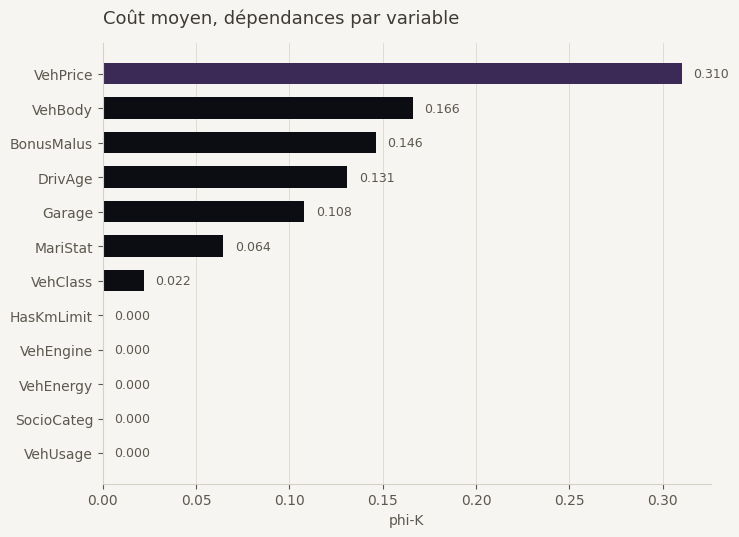

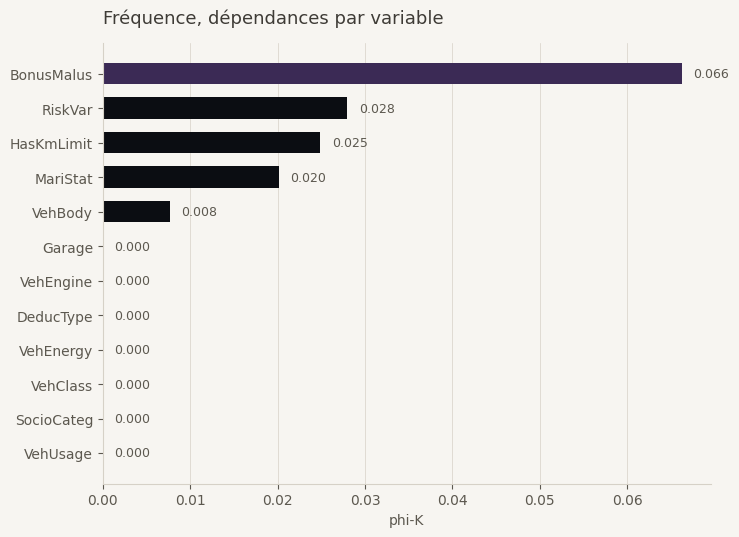

In [9]:
############################ Fonction de représentation
def barres(serie, titre, n = 12):
    serie_triee = serie.sort_values(ascending = True).tail(n)
    couleurs = [VIOLET if valeur == serie_triee.max() else INK for valeur in serie_triee.values]
    fig, ax = plt.subplots(figsize = (7.5, 0.34 * n + 1.4))
    ax.barh(range(len(serie_triee)), serie_triee.values, color = couleurs, height = 0.62)
    ax.set_yticks(range(len(serie_triee)), serie_triee.index)
    ax.set_xlabel("phi-K")
    ax.set_title(titre)
    ax.grid(axis = "x", color = RULE, linewidth = 0.5)
    ax.set_axisbelow(True)
    for position, valeur in enumerate(serie_triee.values):
        ax.text(valeur + serie_triee.max() * 0.02, position, f"{valeur:.3f}", va = "center", fontsize = 9, color = GREY2)
    fig.tight_layout()
    return fig

############################ Affichage des dépendances
barres(classement["phi-K coût moyen"], "Coût moyen, dépendances par variable")
barres(classement["phi-K fréquence"], "Fréquence, dépendances par variable")
plt.show()

<h4>INTENSITÉ ET SIGNIFICATIVITÉ NE SE SUPERPOSENT PAS</h4>

<p>Sur le coût moyen, la variable qui présente l'intensité la plus élevée ne franchit pas
le seuil de 5 pour cent, alors que des variables moins intenses le franchissent. La base
compte 844 sinistres. Le coût est discrétise en dix classes, et VehPrice conserve ses
modalités d'origine : la table de contingence du couple compte plusieurs centaines de
cellules pour 844 observations. La correction de bruit de phi-K le signale par une
p-valeur élevée plutôt que par une valeur écrêtée.</p>

<p>C'est la lecture que recommandent les auteurs : l'intensité dit combien, la
significativité dit si l'effectif permet de le croire. Retenir une variable sur la seule
intensité conduirait ici à estimer un effet sur les vingt-trois modalités présentes,
à partir de 844 sinistres.</p>

In [10]:
############################ Comparaison intensité et significativité, cible coût moyen
lecture_cout = pd.DataFrame({
    "phi-K": classement["phi-K coût moyen"].round(3),
    "Z": Z_cout["Cout"].drop("Cout").round(2),
    "p-valeur": P_cout.round(4),
    "Cases en ligne": [10 if variable in NUM else base_cout[variable].nunique() for variable in classement.index]
}).sort_values("phi-K", ascending = False).head(8)
lecture_cout["Cellules"] = lecture_cout["Cases en ligne"] * 10
lecture_cout["Retenue à 5 %"] = np.where(lecture_cout["p-valeur"] < SEUIL, "oui", "non")
lecture_cout

,phi-K,Z,p-valeur,Cases en ligne,Cellules,Retenue à 5 %
VehPrice,0.310,1.15,0.1260,23,230,non
VehBody,0.166,2.05,0.0201,9,90,oui
BonusMalus,0.146,2.07,0.0192,10,100,oui
DrivAge,0.131,2.23,0.0129,10,100,oui
Garage,0.108,0.71,0.2379,3,30,non
MariStat,0.064,1.24,0.1077,2,20,non
VehClass,0.022,0.59,0.2782,6,60,non
LicAge,0.000,1.17,0.1215,10,100,non


<p class="nt-caption">Nombre de cellules de la table de contingence face à un effectif de
844 sinistres. Les variables quantitatives sont ramenées à dix classes par phi-K.</p>

<div class="nt-section" id="part_5">
  <span class="nt-n">05</span>
  <span class="nt-t">Le même classement par les méthodes classiques</span>
</div>

<p class="nt-lede">Sans indicateur commun, la colonne d'une cible face aux dix-huit
explicatives se remplit avec trois méthodes : Pearson pour les quantitatives, Spearman
pour les ordinales après recodage des rangs, rapport eta pour les nominales.</p>

In [11]:
############################ Rapport de corrélation eta
def rapport_correlation(y, groupe):
    donnees = pd.DataFrame({"y": pd.to_numeric(y, errors = "coerce").values, "g": np.asarray(groupe)}).dropna()
    moyenne = donnees["y"].mean()
    somme_carres_totale = ((donnees["y"] - moyenne) ** 2).sum()
    statistiques = donnees.groupby("g", observed = False)["y"].agg(["mean", "count"])
    somme_carres_expliquee = (statistiques["count"] * (statistiques["mean"] - moyenne) ** 2).sum()
    return np.sqrt(somme_carres_expliquee / somme_carres_totale) if somme_carres_totale > 0 else 0

############################ V de Cramér corrigé du biais
def v_cramer(x, y):
    table = pd.crosstab(x, y)
    nombre_observations = table.values.sum()
    if nombre_observations == 0 or min(table.shape) <= 1:
        return 0
    chi2 = chi2_contingency(table, correction = False)[0]
    phi2 = chi2 / nombre_observations
    phi2_corrige = max(0, phi2 - ((table.shape[1] - 1) * (table.shape[0] - 1)) / (nombre_observations - 1))
    lignes_corrigees = table.shape[0] - ((table.shape[0] - 1) ** 2) / (nombre_observations - 1)
    colonnes_corrigees = table.shape[1] - ((table.shape[1] - 1) ** 2) / (nombre_observations - 1)
    denominateur = min(lignes_corrigees - 1, colonnes_corrigees - 1)
    return np.sqrt(phi2_corrige / denominateur) if denominateur > 0 else 0

############################ Recodage des variables ordinales
def rangs_ordinaux(serie, variable):
    return pd.Series(pd.Categorical(serie, categories = ORD[variable], ordered = True).codes, index = serie.index).replace(-1, np.nan)

############################ Colonne d'une cible, trois méthodes selon le type
def colonne_classique(base, cible):
    lignes = []
    y = base[cible]
    for variable in NUM:
        lignes.append((variable, "Quantitative", "Pearson", pearsonr(y, base[variable])[0]))
    for variable in ORD:
        lignes.append((variable, "Ordinale", "Spearman", spearmanr(y, rangs_ordinaux(base[variable], variable), nan_policy = "omit")[0]))
    for variable in NOM:
        lignes.append((variable, "Nominale", "Rapport eta", rapport_correlation(y, base[variable])))
    return pd.DataFrame(lignes, columns = ["Variable", "Type", "Méthode", "Valeur"]).set_index("Variable")

############################ Application aux deux cibles
classique_freq = colonne_classique(base_freq, "Frequence")
classique_cout = colonne_classique(base_cout, "Cout")

classique = classique_freq[["Type", "Méthode"]].copy()
classique["Fréquence"] = classique_freq["Valeur"].round(3)
classique["Coût moyen"] = classique_cout["Valeur"].round(3)
classique.reindex(classique["Coût moyen"].abs().sort_values(ascending = False).index)

,Type,Méthode,Fréquence,Coût moyen
Variable,,,,
SocioCateg,Nominale,Rapport eta,0.036,0.117
BonusMalus,Quantitative,Pearson,0.031,0.086
VehClass,Nominale,Rapport eta,0.012,0.083
VehBody,Nominale,Rapport eta,0.023,0.076
VehEngine,Nominale,Rapport eta,0.019,0.072
VehEnergy,Nominale,Rapport eta,0.013,0.067
Garage,Nominale,Rapport eta,0.008,0.067
DeducType,Nominale,Rapport eta,0.010,0.055
VehUsage,Nominale,Rapport eta,0.011,0.042


<p class="nt-caption">Les mêmes dix-huit variables, mesurées par trois statistiques
différentes selon leur type.</p>

<div class="nt-figures">
  <div class="nt-fig"><div class="nt-v">3</div><div class="nt-k">méthodes pour une colonne</div></div>
  <div class="nt-fig"><div class="nt-v">6</div><div class="nt-k">croisements de types</div></div>
  <div class="nt-fig"><div class="nt-v">4</div><div class="nt-k">recodages manuels</div></div>
</div>

<p>Le volume de code n'est pas le sujet. Ce tableau pose trois difficultés de lecture.</p>

<div class="nt-list">
  <div class="nt-item">
    <span class="nt-n">01</span>
    <div>
      <p class="nt-h">Les échelles ne sont pas commensurables</p>
      <p class="nt-d">Pearson et Spearman sont signés et varient entre moins un et un. Le
      rapport eta est positif, borné à un, et croît avec le nombre de modalités du groupe.
      Un 0,04 obtenu par Pearson et un 0,04 obtenu par eta ne décrivent pas la même
      quantité.</p>
    </div>
  </div>
  <div class="nt-item">
    <span class="nt-n">02</span>
    <div>
      <p class="nt-h">Le tri mélange trois grandeurs</p>
      <p class="nt-d">Le tableau est trié par valeur absolue, comme on le ferait pour
      choisir par où commencer. En tête arrive la variable nominale la plus riche en
      modalités, mesurée par eta. Le rang obtenu reflète en partie ce nombre de modalités,
      pas seulement la dépendance.</p>
    </div>
  </div>
  <div class="nt-item">
    <span class="nt-n">03</span>
    <div>
      <p class="nt-h">Aucune significativité associée</p>
      <p class="nt-d">Chaque statistique dispose de son propre test, avec ses propres
      hypothèses. Les rassembler dans une colonne unique demanderait de choisir une
      convention commune, qui n'existe pas.</p>
    </div>
  </div>
</div>

In [12]:
############################ Les deux approches côte à côte, cible fréquence
comparaison = classique[["Type", "Méthode"]].copy()
comparaison["Statistique classique"] = classique["Fréquence"]
comparaison["phi-K"] = classement["phi-K fréquence"].round(3)
comparaison["Rang classique"] = classique["Fréquence"].abs().rank(ascending = False).astype(int)
comparaison["Rang phi-K"] = comparaison["phi-K"].rank(ascending = False).astype(int)
comparaison.sort_values("phi-K", ascending = False).head(12)

,Type,Méthode,Statistique classique,phi-K,Rang classique,Rang phi-K
Variable,,,,,,
BonusMalus,Quantitative,Pearson,0.031,0.066,2,1
RiskVar,Ordinale,Spearman,-0.005,0.028,12,2
HasKmLimit,Nominale,Rapport eta,0.004,0.025,14,3
MariStat,Nominale,Rapport eta,0.000,0.020,18,4
VehBody,Nominale,Rapport eta,0.023,0.008,3,5
LicAge,Quantitative,Pearson,-0.002,0.000,16,12
DrivAge,Quantitative,Pearson,0.002,0.000,16,12
VehPrice,Ordinale,Spearman,-0.004,0.000,14,12
VehMaxSpeed,Ordinale,Spearman,-0.004,0.000,14,12


<p class="nt-caption">Une échelle unique et un rang à gauche, trois échelles et un rang non
interprétable à droite.</p>

<div class="nt-section" id="part_6">
  <span class="nt-n">06</span>
  <span class="nt-t">Dépendances entre covariables</span>
</div>

<p class="nt-lede">La colonne de la cible ne suffit pas. Deux variables fortement liées
entre elles apportent la même information au modèle. La question se pose sur les 153
couples d'explicatives, que la voie classique couvre avec quatre statistiques
différentes. Les cibles n'intervenant pas ici, le calcul porte sur l'ensemble des
lignes du portefeuille.</p>

In [13]:
############################ Mesure classique adaptée au couple
def dependance_classique(donnees, variable_x, variable_y):
    type_x = "Quantitative" if variable_x in NUM else "Ordinale" if variable_x in ORD else "Nominale"
    type_y = "Quantitative" if variable_y in NUM else "Ordinale" if variable_y in ORD else "Nominale"
    x, y = donnees[variable_x], donnees[variable_y]
    if type_x == "Quantitative" and type_y == "Quantitative":
        return abs(pearsonr(x, y)[0]), "Pearson"
    if type_x == "Nominale" and type_y == "Nominale":
        return v_cramer(x, y), "V de Cramér"
    if type_x == "Quantitative" and type_y == "Nominale":
        return rapport_correlation(x, y), "Rapport eta"
    if type_x == "Nominale" and type_y == "Quantitative":
        return rapport_correlation(y, x), "Rapport eta"
    if type_x == "Ordinale" and type_y == "Ordinale":
        return abs(spearmanr(rangs_ordinaux(x, variable_x), rangs_ordinaux(y, variable_y), nan_policy = "omit")[0]), "Spearman"
    if type_x == "Quantitative" and type_y == "Ordinale":
        return abs(spearmanr(x, rangs_ordinaux(y, variable_y), nan_policy = "omit")[0]), "Spearman"
    if type_x == "Ordinale" and type_y == "Quantitative":
        return abs(spearmanr(rangs_ordinaux(x, variable_x), y, nan_policy = "omit")[0]), "Spearman"
    return v_cramer(x, y), "V de Cramér"

############################ Base commune d'analyse
donnees_covariables = df[EXPL].dropna().copy()

############################ Matrice des dépendances classiques
matrice_classique = pd.DataFrame(np.eye(len(EXPL)), index = EXPL, columns = EXPL)
matrice_methodes = pd.DataFrame("Identité", index = EXPL, columns = EXPL)
for variable_x, variable_y in combinations(EXPL, 2):
    valeur, methode = dependance_classique(donnees_covariables, variable_x, variable_y)
    matrice_classique.loc[variable_x, variable_y] = valeur
    matrice_classique.loc[variable_y, variable_x] = valeur
    matrice_methodes.loc[variable_x, variable_y] = methode
    matrice_methodes.loc[variable_y, variable_x] = methode

############################ Matrice phi-K
t0 = time.time()
matrice_phik = donnees_covariables.phik_matrix(interval_cols = NUM).loc[EXPL, EXPL]
matrice_significativite = donnees_covariables.significance_matrix(interval_cols = NUM).loc[EXPL, EXPL]
matrice_pvaleurs = matrice_significativite.map(norm.sf)
print(f"Calcul terminé en {time.time() - t0:.1f} s")

############################ Répartition des méthodes employées côté classique
pd.Series([matrice_methodes.loc[x, y] for x, y in combinations(EXPL, 2)]).value_counts().rename("Nombre de couples").to_frame()

Calcul terminé en 41.8 s


,Nombre de couples
V de Cramér,99
Rapport eta,33
Spearman,18
Pearson,3


<p class="nt-caption">Répartition des méthodes nécessaires pour couvrir les 153 couples
d'explicatives.</p>

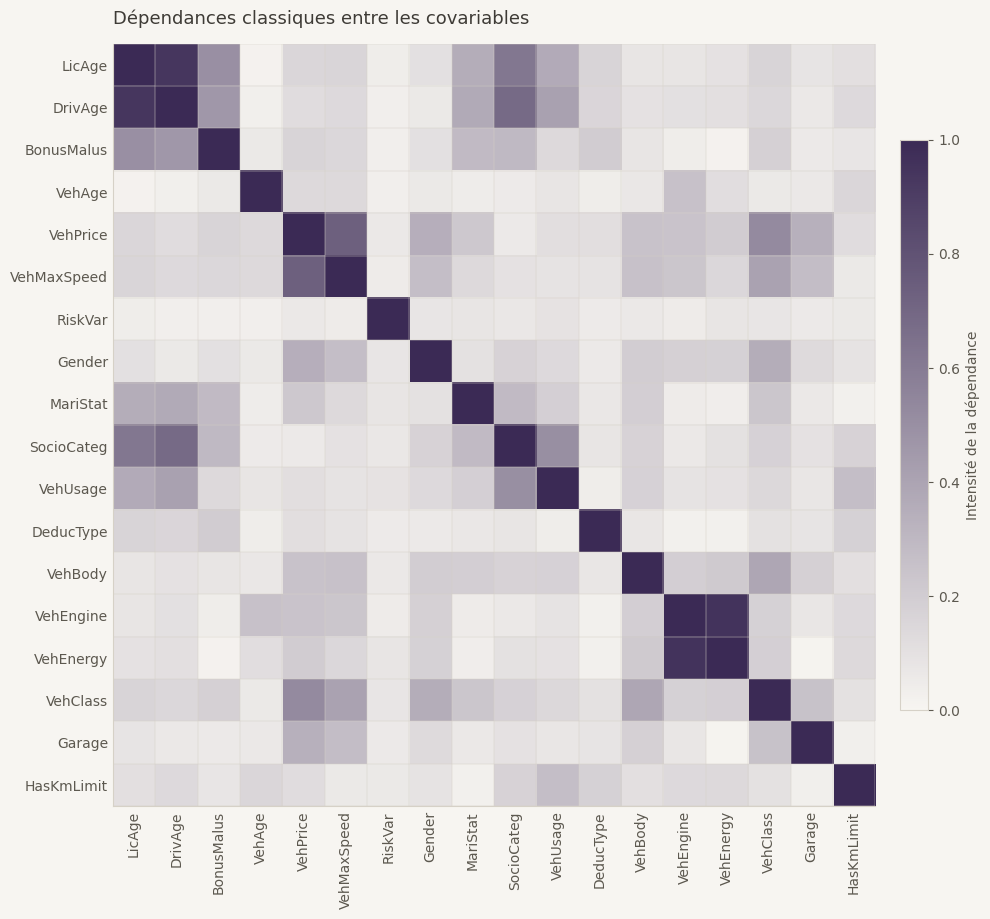

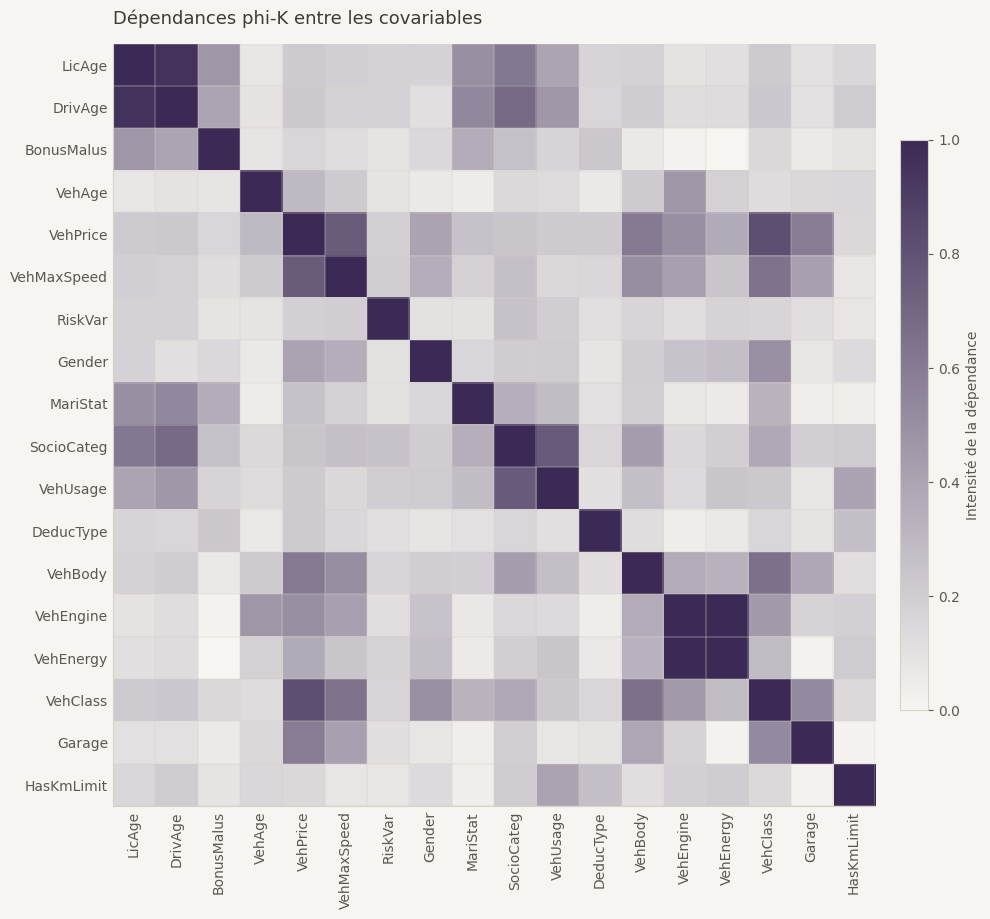

In [14]:
############################ Fonction d'affichage des matrices
def afficher_matrice(matrice, titre):
    taille = max(10, 0.48 * len(matrice.columns))
    fig, ax = plt.subplots(figsize = (taille, taille))
    image = ax.imshow(matrice.values, cmap = CMAP, vmin = 0, vmax = 1, aspect = "equal")
    ax.set_xticks(range(len(matrice.columns)), matrice.columns, rotation = 90)
    ax.set_yticks(range(len(matrice.index)), matrice.index)
    ax.set_title(titre)
    ax.tick_params(axis = "both", length = 0)
    for position in np.arange(-0.5, len(matrice), 1):
        ax.axhline(position, color = RULE, linewidth = 0.35)
        ax.axvline(position, color = RULE, linewidth = 0.35)
    barre = fig.colorbar(image, ax = ax, fraction = 0.035, pad = 0.03)
    barre.set_label("Intensité de la dépendance")
    fig.tight_layout()
    return fig

############################ Affichage des matrices
afficher_matrice(matrice_classique, "Dépendances classiques entre les covariables")
afficher_matrice(matrice_phik, "Dépendances phi-K entre les covariables")
plt.show()

<p class="nt-caption">Même jeu de variables, même ordre d'affichage. La première matrice
juxtapose quatre statistiques bornées différemment, la seconde une seule.</p>

In [15]:
############################ Construction de la comparaison par couple
lignes = []
for variable_x, variable_y in combinations(EXPL, 2):
    lignes.append({
        "Variable 1": variable_x,
        "Variable 2": variable_y,
        "Méthode classique": matrice_methodes.loc[variable_x, variable_y],
        "Statistique classique": matrice_classique.loc[variable_x, variable_y],
        "phi-K": matrice_phik.loc[variable_x, variable_y],
        "Écart": matrice_phik.loc[variable_x, variable_y] - matrice_classique.loc[variable_x, variable_y],
        "p-value phi-K": matrice_pvaleurs.loc[variable_x, variable_y]
    })
comparaison_covariables = pd.DataFrame(lignes)
for colonne in ["Statistique classique", "phi-K", "Écart"]:
    comparaison_covariables[colonne] = comparaison_covariables[colonne].round(3)
comparaison_covariables["p-value phi-K"] = comparaison_covariables["p-value phi-K"].round(4)
comparaison_covariables.sort_values("phi-K", ascending = False).head(15)

,Variable 1,Variable 2,Méthode classique,Statistique classique,phi-K,Écart,p-value phi-K
143,VehEngine,VehEnergy,V de Cramér,0.949,0.994,0.045,0.0
0,LicAge,DrivAge,Pearson,0.935,0.953,0.018,0.0
72,VehPrice,VehClass,V de Cramér,0.527,0.815,0.288,0.0
117,SocioCateg,VehUsage,V de Cramér,0.500,0.759,0.259,0.0
62,VehPrice,VehMaxSpeed,Spearman,0.731,0.752,0.021,0.0
24,DrivAge,SocioCateg,Rapport eta,0.683,0.681,-0.002,0.0
140,VehBody,VehClass,V de Cramér,0.390,0.650,0.259,0.0
84,VehMaxSpeed,VehClass,V de Cramér,0.406,0.642,0.235,0.0
8,LicAge,SocioCateg,Rapport eta,0.621,0.612,-0.009,0.0
69,VehPrice,VehBody,V de Cramér,0.247,0.604,0.358,0.0


<p class="nt-caption">Les quinze couples les plus dépendants au sens de phi-K.</p>

In [16]:
############################ Couples que la mesure classique situe bas et phi-K haut
SEUIL_CLASSIQUE_FAIBLE = 0.20
SEUIL_PHIK_FORT = 0.40
dependances_supplementaires = comparaison_covariables[
    (comparaison_covariables["Statistique classique"] < SEUIL_CLASSIQUE_FAIBLE) &
    (comparaison_covariables["phi-K"] >= SEUIL_PHIK_FORT) &
    (comparaison_covariables["p-value phi-K"] < SEUIL)
].sort_values(["Écart", "phi-K"], ascending = False)
dependances_supplementaires

,Variable 1,Variable 2,Méthode classique,Statistique classique,phi-K,Écart,p-value phi-K
144,VehEngine,VehClass,V de Cramér,0.176,0.449,0.273,0.0
119,SocioCateg,VehBody,V de Cramér,0.171,0.431,0.260,0.0


<p class="nt-caption">Couples dont la mesure classique reste sous 0,20 alors que phi-K
dépasse 0,40 avec une p-valeur inférieure à 5 pour cent.</p>

<p>Ces couples sont ceux sur lesquels les deux lectures divergent le plus. Chacun demande
une vérification avant d'entrer les deux variables dans le même modèle : soit la dépendance
est réelle et la mesure classique la sous-estimé du fait de sa forme ou du typage retenu,
soit elle tient à la discrétisation choisie par phi-K.</p>

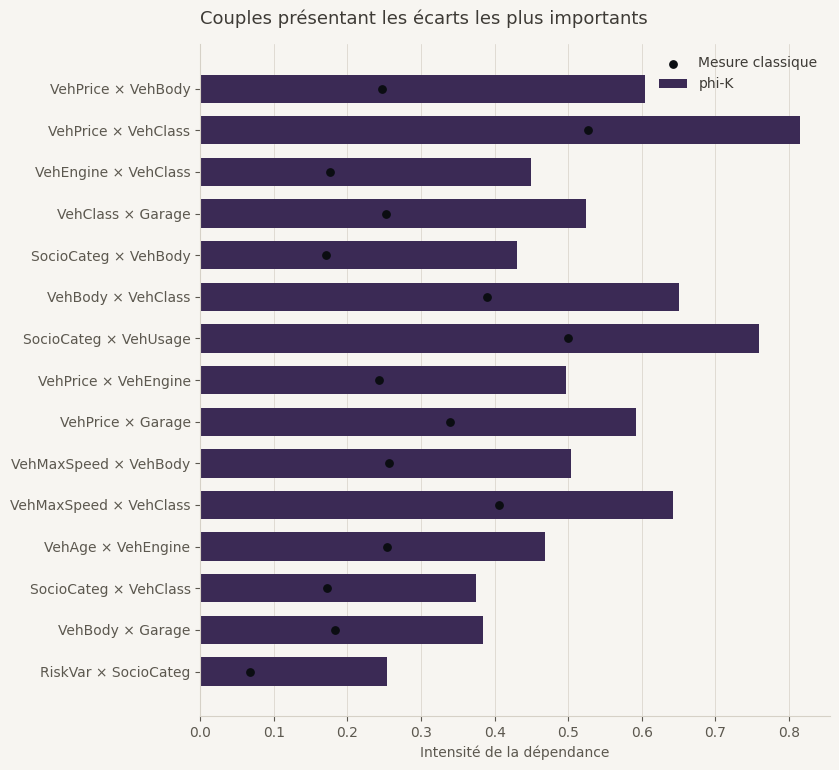

In [17]:
############################ Représentation des écarts les plus importants
N_COUPLES = 15
ecarts_principaux = comparaison_covariables.sort_values("Écart", ascending = False).head(N_COUPLES).copy()
ecarts_principaux["Couple"] = ecarts_principaux["Variable 1"] + " × " + ecarts_principaux["Variable 2"]
ecarts_principaux = ecarts_principaux.sort_values("Écart")

fig, ax = plt.subplots(figsize = (8.5, 0.42 * N_COUPLES + 1.5))
positions = np.arange(len(ecarts_principaux))
ax.barh(positions, ecarts_principaux["phi-K"], height = 0.68, color = VIOLET, label = "phi-K")
ax.scatter(ecarts_principaux["Statistique classique"], positions, color = INK, s = 28, zorder = 3, label = "Mesure classique")
ax.set_yticks(positions, ecarts_principaux["Couple"])
ax.set_xlabel("Intensité de la dépendance")
ax.set_title("Couples présentant les écarts les plus importants")
ax.grid(axis = "x", color = RULE, linewidth = 0.5)
ax.set_axisbelow(True)
ax.legend(frameon = False)
fig.tight_layout()
plt.show()

<p class="nt-caption">Barre violette : phi-K. Point noir : la statistique classique
correspondant au type du couple.</p>

<div class="nt-section" id="part_7">
  <span class="nt-n">07</span>
  <span class="nt-t">Limites</span>
</div>

<div class="nt-list">
  <div class="nt-item">
    <span class="nt-n">01</span>
    <div>
      <p class="nt-h">Aucun sens de variation</p>
      <p class="nt-d">phi-K est borné entre zéro et un. Il donne l'intensité d'une
      dépendance, jamais son sens. Savoir que le coût moyen dépend de la catégorie de prix
      du véhicule ne dit pas si les véhicules chers coûtent plus cher. Pour l'orienter, il
      faut revenir à la table de contingence, ce que l'article traite dans sa section
      consacrée aux valeurs aberrantes.</p>
    </div>
  </div>
  <div class="nt-item">
    <span class="nt-n">02</span>
    <div>
      <p class="nt-h">Une discrétisation à choisir</p>
      <p class="nt-d">Les variables continues sont découpées en classes, dix par défaut.
      Les auteurs montrent que la valeur de phi-K est stable face à ce découpage, la ou
      celle du V de Cramér ne l'est pas, mais le choix reste à documenter dans une note
      méthodologique.</p>
    </div>
  </div>
  <div class="nt-item">
    <span class="nt-n">03</span>
    <div>
      <p class="nt-h">Un coût de calcul supérieur</p>
      <p class="nt-d">La matrice de corrélation reste rapide. La matrice de significativité
      repose sur des simulations de Monte-Carlo par paire et prend ici quelques minutes.
      Sur plusieurs centaines de milliers de lignes, échantillonner avant de lancer le
      calcul.</p>
    </div>
  </div>
  <div class="nt-item">
    <span class="nt-n">04</span>
    <div>
      <p class="nt-h">Un indicateur de tri, pas un modèle</p>
      <p class="nt-d">Le classement oriente la construction du GLM, il ne la remplace pas.
      Il n'établit aucune causalité, ne traite pas les interactions et ne dispense d'aucun
      test au sein du modèle.</p>
    </div>
  </div>
  <div class="nt-item">
    <span class="nt-n">05</span>
    <div>
      <p class="nt-h">Deux choix de périmètre restent ouverts</p>
      <p class="nt-d">Le seuil d'exposition d'un jour écarte les périodes nulles ou
      quasi nulles, mais laisse subsister des fréquences annualisées élevées sur les
      expositions courtes. Et le coût moyen est estimé sur 844 sinistres, effectif qui
      limite la portée des dépendances relevées sur les variables à nombreuses
      modalités.</p>
    </div>
  </div>
</div>

<div class="nt-note">
Référence : M. Baak, R. Koopman, H. Snoek, S. Klous, <em>A new corrélation coefficient
between categorical, ordinal and interval variables with Pearson characteristics</em>,
arXiv:1811.11440, 2019, <à href="https://arxiv.org/abs/1811.11440">arxiv.org/abs/1811.11440</à>.
Implementation : <code>pip install phik</code>, <à href="https://phik.readthedocs.io">phik.readthedocs.io</à>.
Données : freMPL3, CASdatasets, C. Dutang et A. Charpentier.
</div>

<div class="nt-foot">
  <span>ARNAUD MBARGA</span>
  <span class="nt-src">Note technique 01</span>
</div>